In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import platform

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False

In [6]:
project_root = Path.cwd().resolve()
if not (project_root / "Data").exists():
    project_root = project_root.parent

data_path = project_root / "Data" / "ttareung" / "23년도 따릉이 여의나루역 데이터.csv"
df = pd.read_csv(data_path, encoding="utf-8-sig")

df["대여일자"] = pd.to_datetime(df["대여일자"])
df["이용건수"] = pd.to_numeric(df["이용건수"], errors="coerce").fillna(0)
df["요일구분"] = df["대여일자"].dt.dayofweek.map(lambda x: "평일" if x < 5 else "주말")

# 성별/연령대별 raw row를 먼저 날짜-시간 단위로 합산한 뒤 평균을 계산
daily_hourly_usage = (
    df.groupby(["대여일자", "대여시간", "요일구분"], as_index=False)["이용건수"]
    .sum()
)

hourly_average_usage = (
    daily_hourly_usage.groupby(["요일구분", "대여시간"], as_index=False)["이용건수"]
    .mean()
    .rename(columns={"이용건수": "평균이용건수"})
)

hourly_average_usage_pivot = (
    hourly_average_usage.pivot(index="대여시간", columns="요일구분", values="평균이용건수")
    .reindex(range(6,24))
)

display(hourly_average_usage_pivot.round(2))

요일구분,주말,평일
대여시간,,
6,1.78,2.43
7,2.99,11.93
8,4.81,18.51
9,5.48,6.43
10,8.10,5.09
11,8.98,7.09
12,10.73,7.22
13,15.46,8.96
14,25.54,11.72


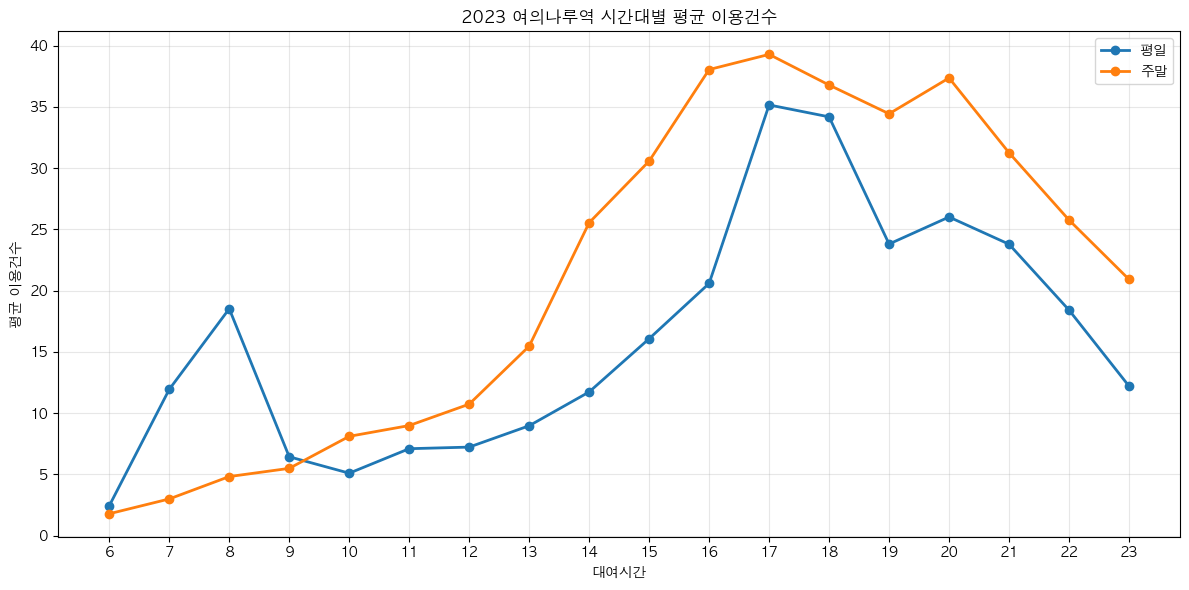

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

for day_type, color in [("평일", "tab:blue"), ("주말", "tab:orange")]:
    ax.plot(
        hourly_average_usage_pivot.index,
        hourly_average_usage_pivot[day_type],
        marker="o",
        linewidth=2,
        label=day_type,
        color=color,
    )

ax.set_title("2023 여의나루역 시간대별 평균 이용건수")
ax.set_xlabel("대여시간")
ax.set_ylabel("평균 이용건수")
ax.set_xticks(range(6,24))
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()